In [2]:
import numpy as np
from matplotlib import pyplot as plt
import perceptron
from perceptron import Perceptron
from sklearn.datasets import make_blobs

perceptron.my_custom_function()

I implemented this function in the file perceptron.py


And here is the link to my source code (source.py): https://github.com/cjy-2001/cjy-2001.github.io/blob/main/posts/perceptron-post/perceptron.py

# Experiment

There are three cases that I want to consider:

- Linearly separable data;

- Non-linearly separable data;

- Data with higher dimensions.

## (1) Linearly Separable

I'd like to show that if the data is linearly separable, then the perceptron algorithm will converge to weight vector 
 describing a separating line (provided that the maximum number of iterations is large enough). To illustrate that idea, I first created 100 data points randomly, then I can use these linearly separable data to draw some visualizations.

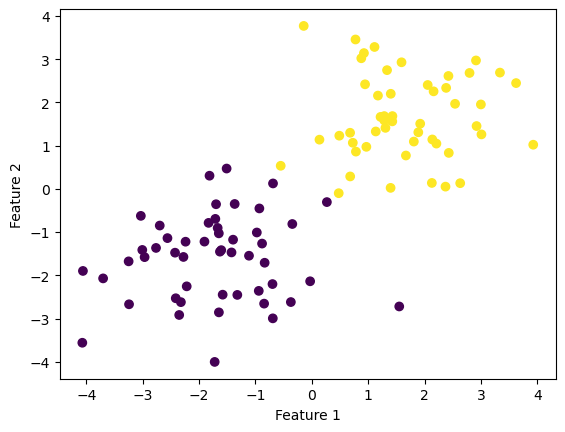

In [3]:
np.random.seed(12345)

n = 100
p_features = 3

X, y = make_blobs(n_samples = 100, n_features = p_features - 1, centers = [(-1.7, -1.7), (1.7, 1.7)])

fig = plt.scatter(X[:,0], X[:,1], c = y)
xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2") 

From the graph, it is easy to tell that the data is linearly separable.

In [4]:
p = Perceptron()
p.fit(X, y, max_steps = 1000)

After implementing my fit function from perceptron.py, I'm able to train my model based on the data. I set the `max_steps` as 1000. Since I recorded the accuracy in the `history` instance variable, I want to draw a graph to see how it evolves.

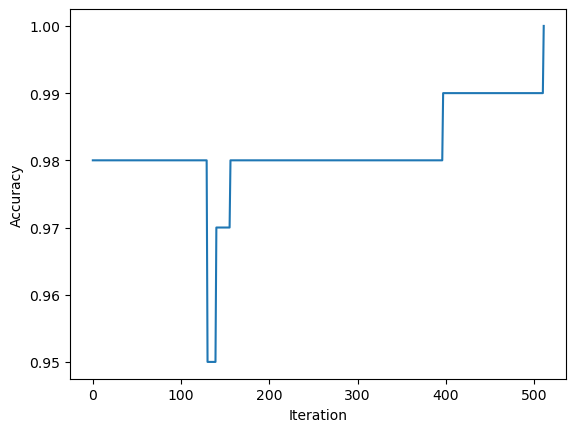

In [5]:
fig = plt.plot(p.history)
xlab = plt.xlabel("Iteration")
ylab = plt.ylabel("Accuracy")

As we can see from the history of accuracy graph, the accuracy gradually increases to 1. After confirming that my model has 100% accuracy, I want to visualize the linear line from the graph.

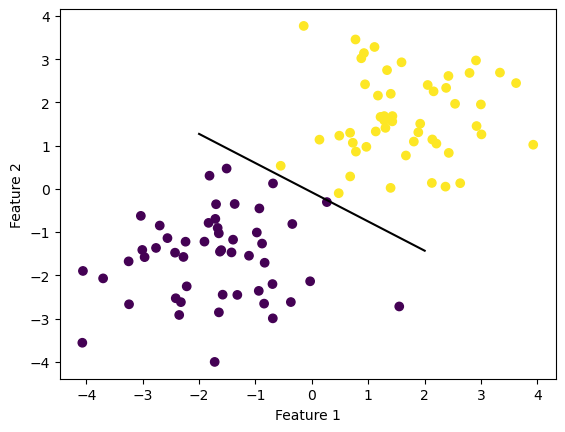

In [6]:
def draw_line(w, x_min, x_max):
  x = np.linspace(x_min, x_max, 101)
  y = -(w[0]*x + w[2])/w[1]
  plt.plot(x, y, color = "black")

fig = plt.scatter(X[:,0], X[:,1], c = y)
fig = draw_line(p.w, -2, 2)

xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2")

This line separates my data perfectly.

## 2 Not Linearly Separable

In this case, I'm going to show that when the data is not linearly separable, the perceptron algorithm will not settle on a final value of, but will instead run until the maximum number of iterations is reached, without achieving perfect accuracy. 

Similarly, I need to first create some data that are not linearly separable.

[0.86, 0.86, 0.86, 0.86, 0.86, 0.8, 0.8, 0.8, 0.8, 0.8]


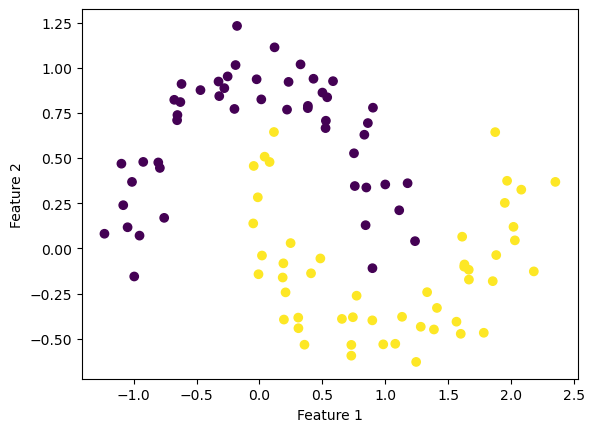

In [7]:
from sklearn.datasets import make_moons

np.random.seed(4)

n = 100

X, y = make_moons(n_samples=100, noise=0.13, random_state=42)

fig = plt.scatter(X[:,0], X[:,1], c = y)
xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2") 

p = Perceptron()
p.fit(X, y, max_steps = 1000)

print(p.history[-10:])

The picture tells us that the data is not linearly separable, then we want to explore how the accuracy performs.

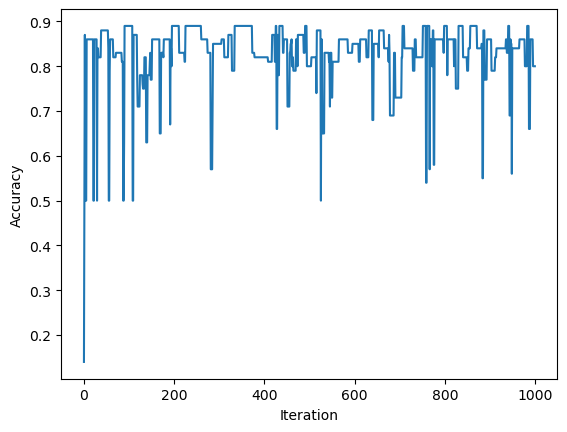

In [8]:
fig = plt.plot(p.history)
xlab = plt.xlabel("Iteration")
ylab = plt.ylabel("Accuracy")

The figure illustrates that the accuracy is oscillating between 0.5 and 0.9, thereby failing to converge to 1. To confirm my idea, I will try to draw a linear separable line.

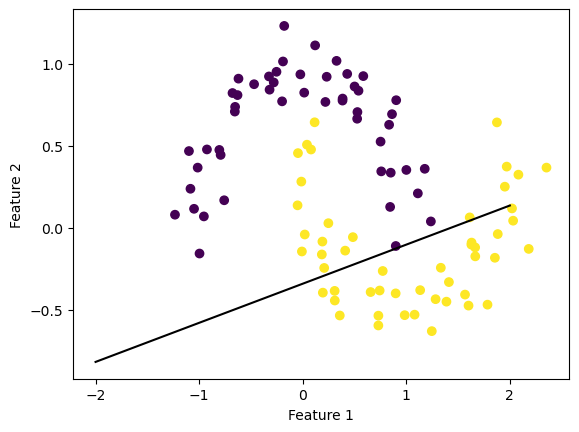

In [9]:
fig = plt.scatter(X[:,0], X[:,1], c = y)
fig = draw_line(p.w, -2, 2)

xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2")

As expected, the line didn't separate the data very well.

## 3 Data with Higher Dimensions

In part 3, I'd like to show that my perceptron algorithm is also able to work in more than 2 dimensions. I'm going to use the data with 5 dimensions as an example to run my algorithm on.

[0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 1.0]


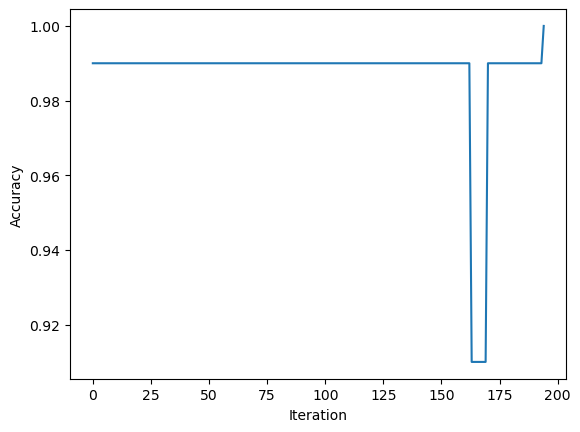

In [10]:
#make some data
np.random.seed(123456)

n = 100
p_features = 5

X, y = make_blobs(n_samples = 100, n_features = p_features - 1, centers = [(-1.7, -1.7), (1.7, 1.7)])

p = Perceptron()
p.fit(X, y, max_steps = 1000)

print(p.history[-10:])

fig = plt.plot(p.history)
xlab = plt.xlabel("Iteration")
ylab = plt.ylabel("Accuracy")

Therefore, according to the evolution of the score over the training period, I believe that the data is linearly separable, because the accuracy has reached 1.

# Additional Questions

_What is the runtime complexity of a single iteration of the perceptron algorithm update as described by Equation 1?_

_Assume that the relevant operations are addition and multiplication. Does the runtime complexity depend on the number of data points? What about the number of features?_

I believe that the runtime complexity will depend more on the number of features instead of number of data points. Because recall from our previous fit function, we only need to consider one single point in doing the weight updating. Therefore, the number of data points won't affect the time complexity. However, when we update the weight, we are performing the matrix multiplication on every feature. Thus, increasing the number of features will largely make the computation harder and more time consuming.

In other words, we know that `X_`'s dimension is n x p. When we are doing dot product of `w` and `X_[i]`, it has $\mathcal{O}(p)$ time complexity. Then we are multiplying the result with a vector of length p, which also has $\mathcal{O}(p)$ time complexity. Because we know that the time complexity will stay the same in the final addition step, we know the final time complexity is $$\mathcal{O}(p) + \mathcal{O}(p) + \mathcal{O}(p) = \mathcal{O}(p),$$ which means the time complexity only depends on the number of dimensions (features).